<a href="https://colab.research.google.com/github/ramyanagavelli463-maker/MyPortfolio/blob/main/Email_Spam_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
import zipfile
import os

zip_path = '/content/sms+spam+collection.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

print("ZIP file extracted successfully!")

ZIP file extracted successfully!


In [5]:
print(os.listdir('/content'))

['.config', 'sms+spam+collection.zip', 'SMSSpamCollection', 'readme', 'sample_data']


In [6]:
['sms+spam+collection.zip', 'SMSSpamCollection', ...]

['sms+spam+collection.zip', 'SMSSpamCollection', Ellipsis]

In [7]:
import pandas as pd

df = pd.read_csv(
    '/content/SMSSpamCollection',
    sep='\t',
    header=None,
    names=['label', 'message']
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [8]:
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5572
Number of columns: 2


In [10]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [11]:
print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

Missing values:
label      0
message    0
dtype: int64

Total missing values: 0


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 403


In [13]:
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (5169, 2)


In [14]:
print(df['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


In [15]:
print(df['label'].value_counts())

label
ham     4516
spam     653
Name: count, dtype: int64


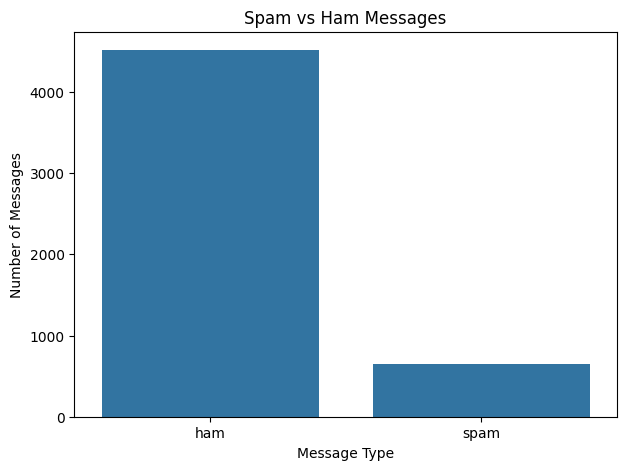

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='label'
)

plt.title('Spam vs Ham Messages')
plt.xlabel('Message Type')
plt.ylabel('Number of Messages')

plt.show()

In [17]:
df['label_num'] = df['label'].map({
    'ham': 0,
    'spam': 1
})

df.head()

,label,message,label_num
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [18]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [20]:
import re
import string

print("Text preprocessing libraries loaded successfully!")

Text preprocessing libraries loaded successfully!


In [21]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

print("clean_text function created successfully!")

clean_text function created successfully!


In [22]:
df['clean_message'] = df['message'].apply(clean_text)

df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [23]:
df['message_length'] = df['clean_message'].apply(len)

df[['label', 'message_length']].head()

,label,message_length
0,ham,102
1,ham,23
2,spam,121
3,ham,43
4,ham,59


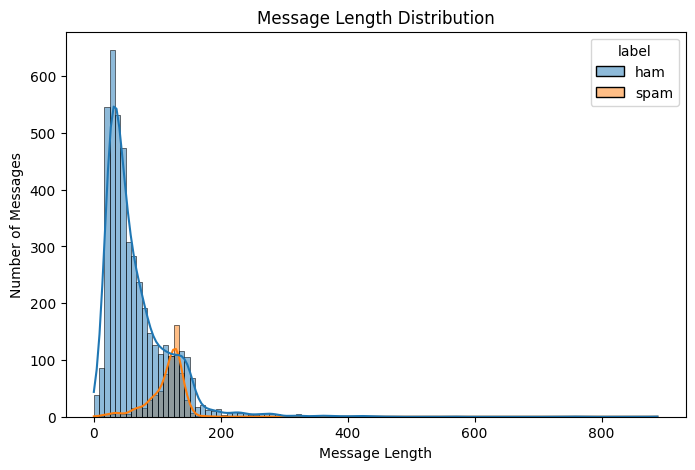

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='message_length',
    hue='label',
    kde=True
)

plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Number of Messages')

plt.show()

In [25]:
average_length = df.groupby('label')['message_length'].mean()

print("Average message length:")
print(average_length)

Average message length:
label
ham      66.290523
spam    114.205207
Name: message_length, dtype: float64


In [26]:
X = df['clean_message']
y = df['label_num']

print("Input messages:")
print(X.head())

print("\nTarget values:")
print(y.head())

Input messages:
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in a wkly comp to win fa cup final ...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: clean_message, dtype: object

Target values:
0    0
1    0
2    1
3    0
4    0
Name: label_num, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))


Training messages: 4135
Testing messages: 1034


In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (4135, 5000)
Testing TF-IDF shape: (1034, 5000)


In [29]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(
    X_train_tfidf,
    y_train
)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [30]:
nb_predictions = nb_model.predict(X_test_tfidf)

print("Predictions generated successfully!")

Predictions generated successfully!


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", nb_accuracy)
print("Precision:", nb_precision)
print("Recall   :", nb_recall)
print("F1 Score :", nb_f1)

Naive Bayes Results
-------------------
Accuracy : 0.9700193423597679
Precision: 1.0
Recall   : 0.7633587786259542
F1 Score : 0.8658008658008658


In [32]:
print(
    classification_report(
        y_test,
        nb_predictions,
        target_names=['Ham', 'Spam']
    )

)



              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       903
        Spam       1.00      0.76      0.87       131

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.97      1034



In [33]:
nb_cm = confusion_matrix(
    y_test,
    nb_predictions
)

print(nb_cm)

[[903   0]
 [ 31 100]]


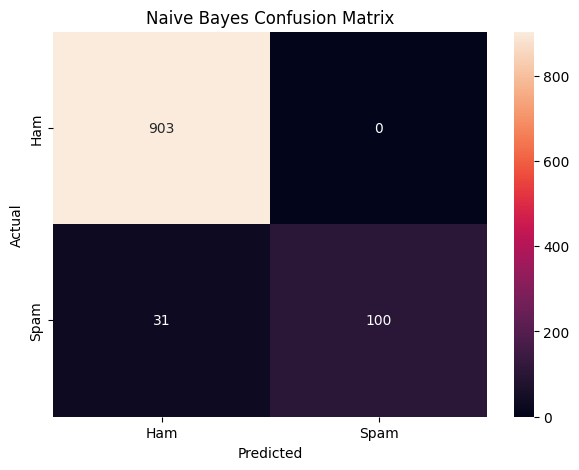

In [34]:
plt.figure(figsize=(7,5))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [35]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    random_state=42
)

svm_model.fit(
    X_train_tfidf,
    y_train
)

print("SVM model trained successfully!")


SVM model trained successfully!


In [36]:
svm_predictions = svm_model.predict(
    X_test_tfidf
)

print("SVM predictions generated successfully!")

SVM predictions generated successfully!


In [37]:
svm_accuracy = accuracy_score(
    y_test,
    svm_predictions
)

svm_precision = precision_score(
    y_test,
    svm_predictions
)

svm_recall = recall_score(
    y_test,
    svm_predictions
)

svm_f1 = f1_score(
    y_test,
    svm_predictions
)

print("SVM Results")
print("-----------")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

SVM Results
-----------
Accuracy : 0.9748549323017408
Precision: 0.9565217391304348
Recall   : 0.8396946564885496
F1 Score : 0.8943089430894309


In [38]:
print(
    classification_report(
        y_test,
        svm_predictions,
        target_names=['Ham', 'Spam']
    )
)



              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       903
        Spam       0.96      0.84      0.89       131

    accuracy                           0.97      1034
   macro avg       0.97      0.92      0.94      1034
weighted avg       0.97      0.97      0.97      1034



In [39]:
svm_cm = confusion_matrix(
    y_test,
    svm_predictions
)

print(svm_cm)

[[898   5]
 [ 21 110]]


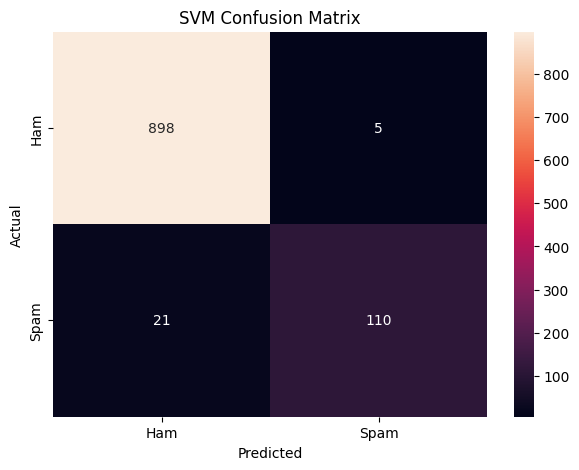

In [40]:
plt.figure(figsize=(7,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt='d',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [41]:
results = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'SVM'
    ],
    'Accuracy': [
        nb_accuracy,
        svm_accuracy
    ],
    'Precision': [
        nb_precision,
        svm_precision
    ],
    'Recall': [
        nb_recall,
        svm_recall
    ],
    'F1 Score': [
        nb_f1,
        svm_f1
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.970019,1.000000,0.763359,0.865801
1,SVM,0.974855,0.956522,0.839695,0.894309


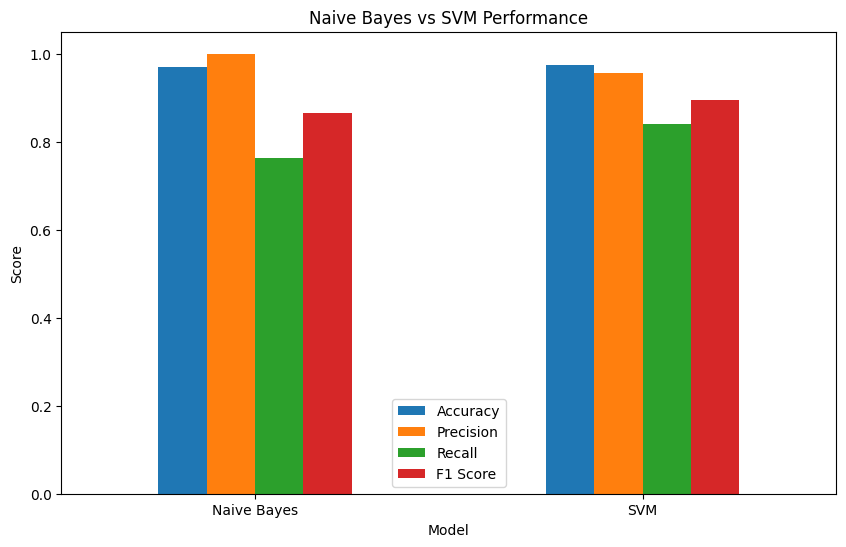

In [42]:
results_plot = results.set_index('Model')

results_plot.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Naive Bayes vs SVM Performance')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)

plt.show()

In [43]:
!pip install wordcloud -q

In [44]:
from wordcloud import WordCloud

print("WordCloud imported successfully!")

WordCloud imported successfully!


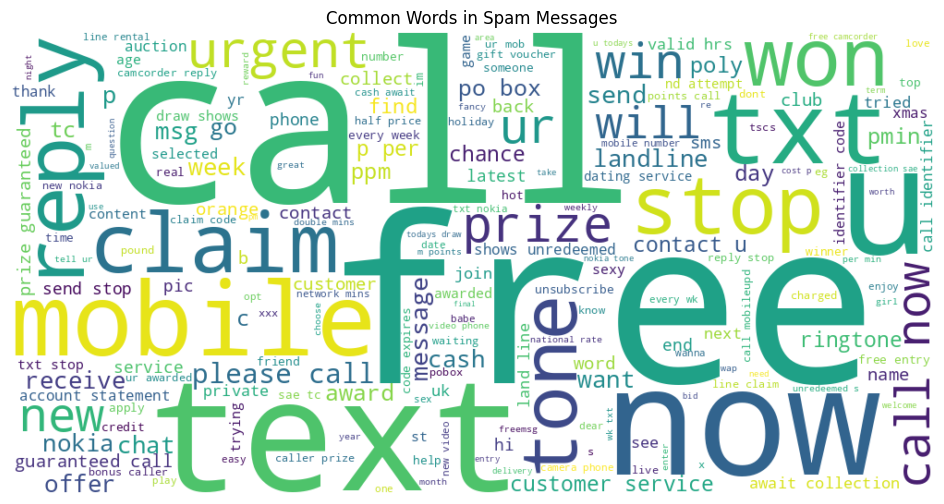

In [45]:
spam_text = ' '.join(
    df[df['label'] == 'spam']['clean_message']
)

spam_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(spam_text)

plt.figure(figsize=(12,6))

plt.imshow(
    spam_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')
plt.title('Common Words in Spam Messages')

plt.show()

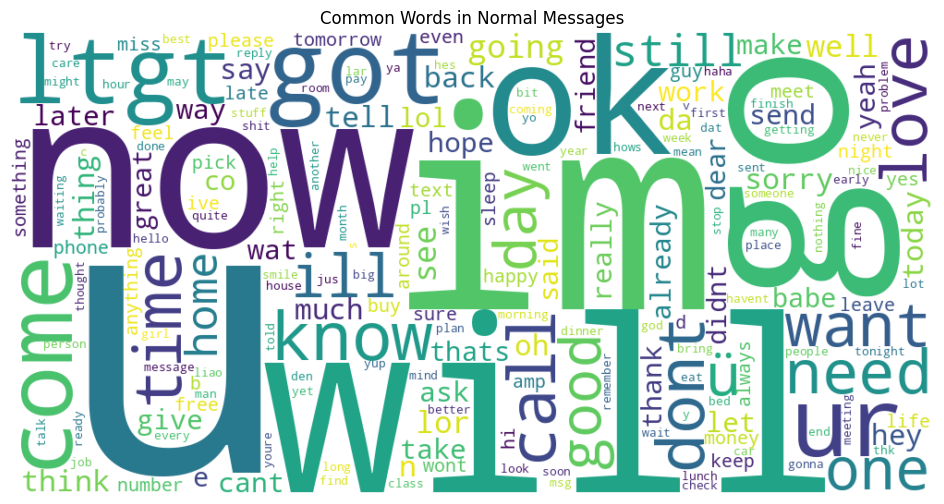

In [46]:
ham_text = ' '.join(
    df[df['label'] == 'ham']['clean_message']
)

ham_wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(ham_text)

plt.figure(figsize=(12,6))

plt.imshow(
    ham_wordcloud,
    interpolation='bilinear'
)

plt.axis('off')
plt.title('Common Words in Normal Messages')

plt.show()

In [47]:
message = "Congratulations! You have won a free prize. Click now to claim your reward!"

cleaned_message = clean_text(message)

message_tfidf = tfidf.transform(
    [cleaned_message]
)

prediction = svm_model.predict(
    message_tfidf
)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

Prediction: SPAM


In [48]:
message = "Hi, are you coming to college tomorrow?"

cleaned_message = clean_text(message)

message_tfidf = tfidf.transform(
    [cleaned_message]
)

prediction = svm_model.predict(
    message_tfidf
)

if prediction[0] == 1:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

Prediction: NOT SPAM


In [49]:
def predict_message(message):

    cleaned_message = clean_text(message)

    message_tfidf = tfidf.transform(
        [cleaned_message]
    )

    prediction = svm_model.predict(
        message_tfidf
    )

    if prediction[0] == 1:
        return "SPAM"
    else:
        return "NOT SPAM"

In [50]:
print(
    predict_message(
        "Congratulations! You won a free lottery prize!"
    )
)

SPAM


In [51]:
print(
    predict_message(
        "Please send me the assignment when you are free."
    )
)

NOT SPAM


In [52]:
test_messages = [
    "Congratulations! You won a free prize!",
    "Can you call me when you reach home?",
    "URGENT! Claim your cash reward now!",
    "Don't forget to attend the meeting tomorrow.",
    "You have been selected for a free vacation!"
]

for msg in test_messages:
    print("Message:", msg)
    print("Prediction:", predict_message(msg))
    print("-" * 60)

Message: Congratulations! You won a free prize!
Prediction: SPAM
------------------------------------------------------------
Message: Can you call me when you reach home?
Prediction: NOT SPAM
------------------------------------------------------------
Message: URGENT! Claim your cash reward now!
Prediction: SPAM
------------------------------------------------------------
Message: Don't forget to attend the meeting tomorrow.
Prediction: NOT SPAM
------------------------------------------------------------
Message: You have been selected for a free vacation!
Prediction: SPAM
------------------------------------------------------------


In [53]:
final_results = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision',
        'Recall',
        'F1 Score'
    ],
    'Naive Bayes': [
        nb_accuracy,
        nb_precision,
        nb_recall,
        nb_f1
    ],
    'SVM': [
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ]
})

final_results

,Metric,Naive Bayes,SVM
0,Accuracy,0.970019,0.974855
1,Precision,1.000000,0.956522
2,Recall,0.763359,0.839695
3,F1 Score,0.865801,0.894309


# 📧 Email Spam Detection Using Machine Learning

## Objective

The objective of this project is to build a machine learning model that classifies SMS messages as spam or normal messages.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TF-IDF
- Naive Bayes
- Support Vector Machine (SVM)
- WordCloud
- Google Colab

# 📧 Email Spam Detection Using Machine Learning

## Objective

The objective of this project is to build a machine learning model that classifies SMS messages as spam or normal messages.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- TF-IDF
- Naive Bayes
- Support Vector Machine (SVM)
- WordCloud
- Google Colab

## Conclusion

In this project, a machine learning system was developed to classify SMS messages as spam or normal messages.

The SMS Spam Collection dataset was cleaned and explored before applying machine learning techniques. Text preprocessing was performed to remove unnecessary characters and standardize the messages.

TF-IDF was used to convert text into numerical features. Multinomial Naive Bayes and Support Vector Machine models were trained and evaluated.

The models were evaluated using accuracy, precision, recall and F1 score. Confusion matrices were also generated to analyze the classification results.

Finally, the trained model was tested on new messages to demonstrate how machine learning can be used for spam detection.

In [54]:
import re
import string